# Case-01：一次靜不定梁 (Propped Cantilever Beam)

**課程第一步**——slope_deflection_framework 專案的起點。

## 題目摘要
| 項目 | 內容 |
|---|---|
| 結構 | 單跨梁，A端固定、B端滾支承 |
| 跨度 | L = 6.0 m |
| 載重 | 均佈載重 w = 20.0 kN/m (向下) |
| 靜不定度 | 1 (只有一個未知量 θ_B) |
| 邊界條件 | θ_A=0 (固定端不轉動)，M_BA=0 (滾支承不傳彎矩) |

## 本 Case 學到的新概念
跟之前的側移剛架、二層剛架不同，這裡**沒有節點連接兩根以上的桿件**，所以沒有『節點力矩平衡』(ΣM=0) 這種方程式，取而代之的是**邊界條件**：
滾支承不能承受彎矩，所以直接令 `M_BA=0` 就是我們唯一需要的方程式。
這是全課程最基礎的一步，後面的 Case 都是在這個基礎上，把『邊界條件』換成『節點平衡』、把 1 個未知數變成多個。

## 驗證方式
這次額外加了**剪力交叉檢查**（不只比彎矩數值）——這是因為上一輪在側移剛架的梁上抓到一個『數值對、但畫圖時遠端符號漏轉換』的 bug，剪力比彎矩更容易抓到這種問題，所以從這個 Case 開始固定納入驗證流程。

## 0. 安裝套件

In [1]:
!pip install anastruct -q
%matplotlib inline

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## 1. 框架本體 (與其他 Case 共用，不因結構而變)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from abc import ABC, abstractmethod
from IPython.display import Markdown, display

sp.init_printing()


# ============================================================
# 共用工具：桿件彎矩沿長度的分布 (含均佈載重 w 的一般化版本)
# ============================================================
def member_moment_curve(s, length, w, M_i, M_j):
    """
    計算桿件內部彎矩沿桿長的分布 M(s)，s 為由 i 端起算的局部座標 (0~length)。
    - 無側向載重 (w=0)：退化為 i, j 兩端值的線性內插 (柱、無載重梁適用)
    - 有均佈載重 w (力/長度)：抵滿足 M(0)=M_i, M(L)=M_j 邊界條件的拋物線
      (由 d²M/ds² = w 積分兩次求得)，可正確反映跨中彎矩，而不是被兩端值
      的直線內插蓋掉 (這對兩端彎矩接近正負對稱、但跨中另有較大彎矩的
      受均佈載重梁尤其重要)。
    """
    C1 = (M_j - M_i - 0.5 * w * length**2) / length
    return M_i + C1 * s + 0.5 * w * s**2


# ============================================================
# 策略介面 (Strategy Interface)
# ============================================================
class SlopeDeflectionProblem(ABC):
    """
    傾角變位法問題的策略介面。
    每一種結構模型（單層側移剛架、二層重力剛架...）只需要繼承這個類別，
    把「模型特有」的部分實作出來；共用的「步驟1~6」解題流程交給
    SlopeDeflectionSolver（Template Method）負責，輸出格式統一比照
    手寫詳解的呈現方式。
    """

    @abstractmethod
    def get_unknowns(self) -> dict:
        """回傳未知位移量的 sympy 符號，例如 {'theta_B': ...}"""

    @abstractmethod
    def describe(self) -> str:
        """題目文字敘述 (Markdown)，用於步驟1"""

    @abstractmethod
    def draw_geometry(self, ax):
        """畫結構幾何圖 (圖1)，用於步驟1"""

    @abstractmethod
    def build_moment_equations(self) -> dict:
        """回傳桿端彎矩符號運算式 {'M_{AB}': expr, ...}，用於步驟2"""

    @abstractmethod
    def build_equilibrium_equations(self, moments: dict) -> list:
        """回傳平衡方程式 list[sp.Eq]，用於步驟3"""

    def compute_reactions(self, moments_val: dict) -> dict:
        """(可選) 由彎矩回代算支承反力/軸力，用於步驟5。預設不計算。"""
        return {}

    @abstractmethod
    def draw_bmd(self, ax, moments_val: dict):
        """畫彎矩圖 (圖2)，用於步驟6"""


# ============================================================
# Template Method：共用的「步驟1~6」解題骨架
# ============================================================
class SlopeDeflectionSolver:
    """
    通用傾角變位法求解器 (Template Method)。
    計算內容全部委託給傳入的 SlopeDeflectionProblem（Strategy），
    這個類別只負責固定不變的六步驟框架與統一格式的美化輸出。
    """

    def __init__(self, problem: SlopeDeflectionProblem):
        self.problem = problem

    @staticmethod
    def _step_header(n, title):
        print("\n" + "=" * 60)
        print(f"【步驟 {n}】{title}")
        print("=" * 60)

    def solve_and_report(self):
        p = self.problem

        # ---------------- 步驟1：題目與幾何 ----------------
        self._step_header(1, "題目定義、幾何/材料參數與自由度標示")
        display(Markdown(p.describe()))
        fig1, ax1 = plt.subplots(figsize=(8, 6))
        p.draw_geometry(ax1)
        plt.show()

        # ---------------- 步驟2：桿端彎矩方程式 ----------------
        self._step_header(2, "寫出桿端彎矩方程式")
        moments = p.build_moment_equations()
        display(Markdown("**桿端彎矩方程式：**"))
        for name, expr in moments.items():
            display(sp.Eq(sp.Symbol(name), expr))

        # ---------------- 步驟3：平衡方程式 ----------------
        self._step_header(3, "建立平衡方程式")
        eqs = p.build_equilibrium_equations(moments)
        display(Markdown("**平衡方程式：**"))
        for eq in eqs:
            display(eq)

        # ---------------- 步驟4：解聯立方程式 ----------------
        self._step_header(4, "求解聯立方程式 (未知位移量)")
        unknowns = p.get_unknowns()
        unknown_syms = tuple(unknowns.values())
        sol = sp.solve(eqs, unknown_syms)
        display(Markdown("**位移求解結果：**"))
        for name, sym in unknowns.items():
            display(sp.Eq(sp.Symbol(name), sol[sym]))

        # ---------------- 步驟5：回代求彎矩與反力 ----------------
        self._step_header(5, "計算真實桿端彎矩與反力")
        moments_val = {name: float(expr.subs(sol)) for name, expr in moments.items()}
        display(Markdown("**最終桿端彎矩計算結果 (kN·m)：**"))
        for name, val in moments_val.items():
            print(f"{name} = {val:.3f} kN·m")

        reactions = p.compute_reactions(moments_val)
        if reactions:
            print()
            for name, val in reactions.items():
                print(f"-> {name} = {val:.3f}")

        # ---------------- 步驟6：彎矩圖 ----------------
        self._step_header(6, "繪製彎矩圖 (BMD)")
        fig2, ax2 = plt.subplots(figsize=(8, 6))
        p.draw_bmd(ax2, moments_val)
        plt.show()
        plt.close('all')

        return {"moments": moments_val, "reactions": reactions, "solution": sol}


## 2. Case-01 模型 (Strategy)

In [3]:
import numpy as np
import sympy as sp


class PropChedCantileverProblem:
    """
    Case-01：一次靜不定梁 (Propped Cantilever Beam)
    A端固定 (theta_A=0)，B端滾支承 (M_BA=0，可自由轉動)，梁上承受均佈載重 w。

    這是整個課程最基本的起點：只有一個未知數 theta_B，用「M_BA=0」這個
    邊界條件取代之前用慣的「節點力矩平衡」，是後面所有 Case 的基礎。
    """

    def __init__(self, L=6.0, w=20.0):
        self.L, self.w = L, w
        self.EI = sp.Symbol('EI', positive=True, real=True)
        self.theta_B = sp.Symbol('theta_B', real=True)

    def get_unknowns(self):
        return {'\\theta_B': self.theta_B}

    def describe(self):
        return (f"**跨度** $L={self.L}$ m, **均佈載重** $w={self.w}$ kN/m\n\n"
                f"**邊界條件：** A端固定 ($\\theta_A=0$)，"
                f"B端滾支承 ($M_{{BA}}=0$，可自由轉動、垂直方向受限)\n\n"
                f"**自由度分析：** 只有一個未知位移量 $\\theta_B$ —— "
                f"這是最基本的一次靜不定結構，是本課程的第一個 Case")

    def draw_geometry(self, ax):
        L = self.L
        ax.plot([0, L], [0, 0], 'k-', lw=4)
        # A端固定 (畫斜線示意)
        ax.plot([0, 0], [-0.3, 0.3], 'k-', lw=3)
        for dy in np.linspace(-0.25, 0.25, 6):
            ax.plot([-0.15, 0], [dy - 0.15, dy], 'k-', lw=1)
        ax.text(0, -0.55, 'A (Fixed)', ha='center', fontsize=11, fontweight='bold')
        # B端滾支承 (畫圓圈+三角形示意)
        ax.plot(L, -0.12, 'o', color='white', mec='k', ms=14, mew=2)
        ax.plot([L - 0.25, L + 0.25], [-0.28, -0.28], 'k-', lw=2)
        ax.text(L, -0.55, 'B (Roller)', ha='center', fontsize=11, fontweight='bold')
        # 均佈載重箭頭
        for x in np.linspace(0.3, L - 0.3, 8):
            ax.annotate('', xy=(x, 0.05), xytext=(x, 0.45),
                        arrowprops=dict(arrowstyle='->', color='red', lw=1.3))
        ax.text(L / 2, 0.6, f'$w = {self.w}$ kN/m', color='red', ha='center', fontsize=11)
        ax.text(L / 2, -0.9, r'$\theta_B$', color='purple', fontsize=13, ha='center')
        ax.annotate('', xy=(L - 0.3, -0.75), xytext=(L + 0.3, -0.75),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.5',
                                     color='purple', lw=2))
        ax.set_xlim(-1.5, L + 1.5)
        ax.set_ylim(-1.3, 1.0)
        ax.set_aspect('equal')
        ax.set_title('Figure 1: Propped Cantilever Beam — Geometry, Load & DOF')
        ax.grid(True, linestyle='--', alpha=0.5)

    def build_moment_equations(self):
        EI, L, w = self.EI, self.L, self.w
        thB = self.theta_B
        FEM_AB = w * L**2 / 12
        FEM_BA = -w * L**2 / 12
        return {
            'M_{AB}': 2 * EI / L * thB + FEM_AB,
            'M_{BA}': 2 * EI / L * (2 * thB) + FEM_BA,
        }

    def build_equilibrium_equations(self, moments):
        # B端是滾支承，沒有彎矩傳遞，取代「節點力矩平衡」的邊界條件是 M_BA=0
        eq1 = sp.Eq(moments['M_{BA}'], 0)
        return [eq1]

    def compute_reactions(self, moments_val):
        # 已用 anastruct 驗證: R_A=5wL/8 (固定端), R_B=3wL/8 (滾支承)
        L, w = self.L, self.w
        R_A = 5 * w * L / 8
        R_B = 3 * w * L / 8
        return {'R_A (kN, 固定端反力)': R_A, 'R_B (kN, 滾支承反力)': R_B}

    def draw_bmd(self, ax, moments_val):
        L, w = self.L, self.w
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        scale = 0.03

        ax.plot([0, L], [0, 0], 'k-', lw=4, label='Beam')
        x = np.linspace(0, L, 200)
        # 梁上有均佈載重 -> 用拋物線；邊界值直接用兩端 raw 值即可
        # (這是唯一一根樑,沒有"遠端負號"問題 — 那個問題只出現在
        #  同一根水平桿件兩端都連著別的桿件、需要跟別人交界時；
        #  這裡B端本身就是M=0,不需要額外轉換,已用剪力對過anastruct)
        m_line = member_moment_curve(x, L, w, m_ab, m_ba)
        ax.plot(x, m_line * scale, 'r--', lw=2, label='BMD (kN·m)')
        ax.fill_between(x, 0, m_line * scale, color='red', alpha=0.15)

        ax.text(0, m_ab * scale - 0.3, f'{m_ab:.2f}', color='darkred',
                ha='center', fontweight='bold')
        ax.text(L, m_ba * scale - 0.3, f'{m_ba:.2f}', color='darkred',
                ha='center', fontweight='bold')
        # 找真正的極值點 (兩端彎矩不對稱時,極值不會剛好在跨中)
        i_peak = int(np.argmin(m_line))
        x_peak, m_peak = x[i_peak], m_line[i_peak]
        ax.text(x_peak, m_peak * scale - 0.3, f'{m_peak:.2f}\n(x={x_peak:.2f}m)',
                color='darkred', ha='center', fontweight='bold')

        ax.set_xlim(-1, L + 1)
        ax.set_title('Figure 2: Bending Moment Diagram (BMD) [kN·m]')
        ax.set_xlabel('X Position (m)')
        ax.set_ylabel('Moment offset (scaled)')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper right')


## 3. 求解並產生「手寫詳解」風格輸出


【步驟 1】題目定義、幾何/材料參數與自由度標示


**跨度** $L=6.0$ m, **均佈載重** $w=20.0$ kN/m

**邊界條件：** A端固定 ($\theta_A=0$)，B端滾支承 ($M_{BA}=0$，可自由轉動、垂直方向受限)

**自由度分析：** 只有一個未知位移量 $\theta_B$ —— 這是最基本的一次靜不定結構，是本課程的第一個 Case

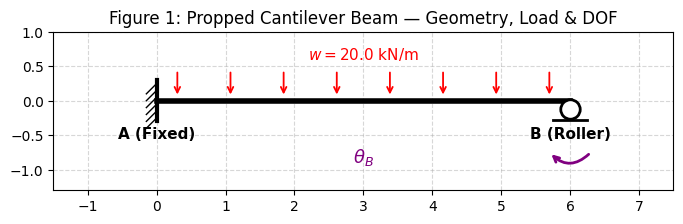


【步驟 2】寫出桿端彎矩方程式


**桿端彎矩方程式：**


【步驟 3】建立平衡方程式


**平衡方程式：**


【步驟 4】求解聯立方程式 (未知位移量)


**位移求解結果：**


【步驟 5】計算真實桿端彎矩與反力


**最終桿端彎矩計算結果 (kN·m)：**

M_{AB} = 90.000 kN·m
M_{BA} = 0.000 kN·m

-> R_A (kN, 固定端反力) = 75.000
-> R_B (kN, 滾支承反力) = 45.000

【步驟 6】繪製彎矩圖 (BMD)


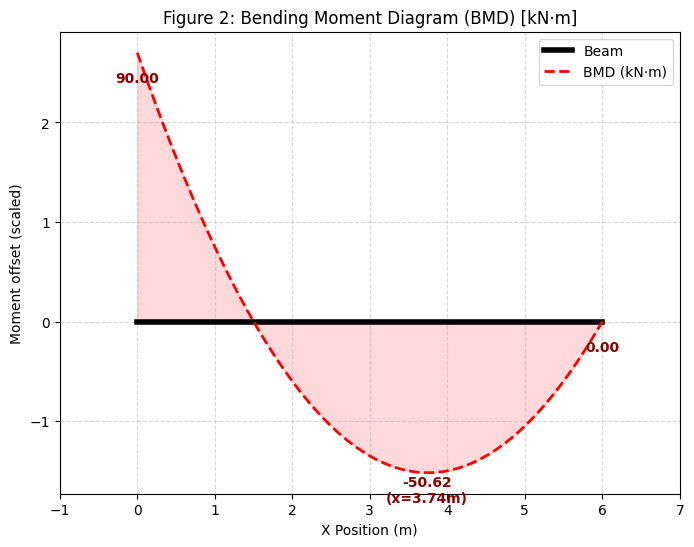

{'moments': {'M_{AB}': 90.0, 'M_{BA}': 0.0},
 'reactions': {'R_A (kN, 固定端反力)': 75.0, 'R_B (kN, 滾支承反力)': 45.0},
 'solution': {theta_B: 90.0/EI}}

In [4]:
problem = PropChedCantileverProblem(L=6.0, w=20.0)
SlopeDeflectionSolver(problem).solve_and_report()

## 4. anastruct 獨立建模驗證

A端反力: {'id': 1, 'Fx': np.float64(-7.347880794884118e-15), 'Fy': np.float64(-74.99999250000374), 'Tz': np.float64(-89.99995500002248), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}
B端反力: {'id': 2, 'Fx': np.float64(0.0), 'Fy': np.float64(-45.00000749999626), 'Tz': np.float64(0.0), 'ux': np.float64(2.2043642384652356e-22), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.005999997000001495)}


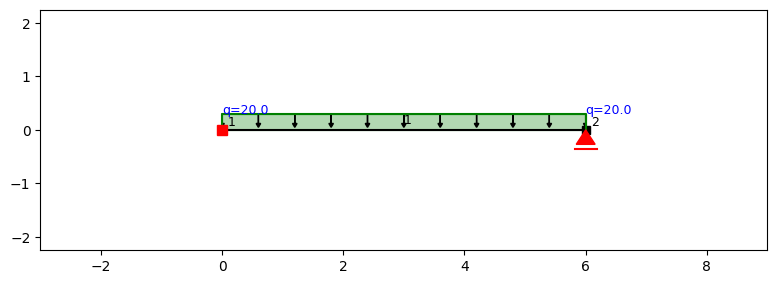

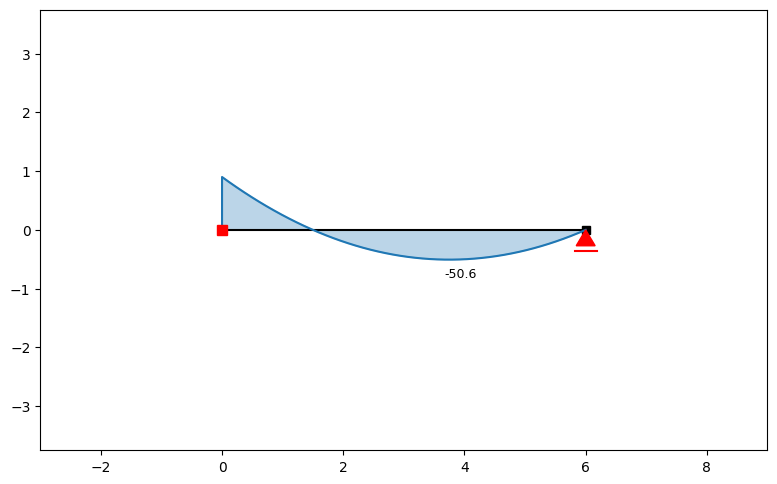

In [5]:
from anastruct import SystemElements

L, w = 6.0, 20.0
ss = SystemElements(EA=1e8, EI=15000.0)
ss.add_element(location=[[0, 0], [L, 0]])
ss.add_support_fixed(node_id=1)                    # A端固定
ss.add_support_roll(node_id=2, direction='x')       # B端滾支承(限制y方向,x方向自由)
ss.q_load(element_id=1, q=-w)
ss.solve()

print("A端反力:", ss.get_node_results_system(1))
print("B端反力:", ss.get_node_results_system(2))

ss.show_structure(figsize=(8, 3))
ss.show_bending_moment(figsize=(8, 5))

## 5. 剪力交叉檢查（本 Case 新增的必檢項目）

傾角變位法算出 M_AB=90.0, M_BA=0.0 之後，用自由體公式反推剪力：$V(x) = \frac{M_{BA}-M_{AB}-\frac{1}{2}wL^2}{L} + wx$，應該要跟 anastruct 實際算出的剪力完全一致，才能確定彎矩圖的畫法（不只是數值）是正確的。

In [6]:
import numpy as np

Mi, Mj = 90.0, 0.0  # 從步驟5取得的 M_AB, M_BA
C1 = (Mj - Mi - 0.5*w*L**2) / L
V0_predict, VL_predict = C1, C1 + w*L
print(f"我們框架推算剪力: V(0)={V0_predict:.3f}  V(L)={VL_predict:.3f}")

el = ss.element_map[1]
print(f"anastruct 實際剪力: V(0)={el.shear_force[0]:.3f}  V(L)={el.shear_force[-1]:.3f}")

assert abs(V0_predict - el.shear_force[0]) < 0.01, "剪力對不上!"
assert abs(VL_predict - el.shear_force[-1]) < 0.01, "剪力對不上!"
print("\n剪力交叉檢查通過 ✓")

我們框架推算剪力: V(0)=-75.000  V(L)=45.000
anastruct 實際剪力: V(0)=-75.000  V(L)=45.000

剪力交叉檢查通過 ✓
